## Equilibrating a TIP3P Water Box

#### The need for equilibration ####

Water boxes need to be equilibrated, by using a molecular simulation to stabilise the water molecules, to find its most natural molecular state.

Importing modules

In [1]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

In [14]:
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

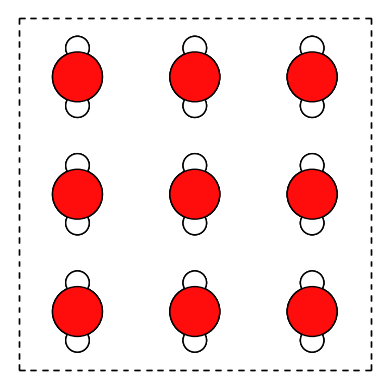

In [16]:
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
ax.set_axis_off()

Contraining internel degrees of freedom. Constrain interatomic distances, O-H1, O-H2 and H1-H2 for each molecule.

In [17]:
water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

Equilibrate smaller box of water

In [18]:
# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)
md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


True

 Visualise equilibration trajectories
 

In [6]:
from ase.io import read
from ase.visualize import view

In [9]:
water_uneq = read('tip3p_27mol_equil.traj')
view(water_uneq)

<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/testing/bin/p...>

In [10]:
water_eq = read('tip3p_216mol_equil.traj')
view(water_eq)

<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/testing/bin/p...>

## Perform basic MD simulations using ASE.

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance
from asap3 import EMT
from ase.calculators.tip4p import TIP3P
from ase import units
from ase.cluster.cubic import FaceCenteredCubic as ClusterFCC
from ase.io.trajectory import Trajectory
from ase.lattice.cubic import FaceCenteredCubic as LatticeFCC
from ase.md.langevin import Langevin  # for later NPT simulations
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms



1. Visualise initial structure

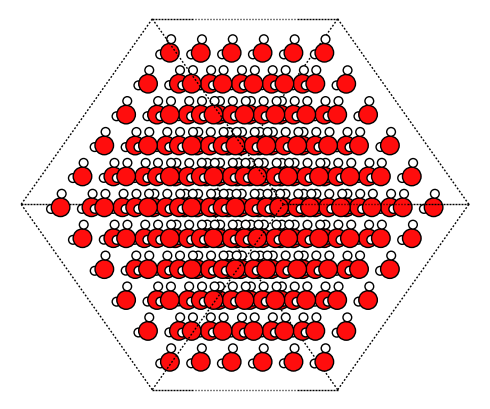

In [21]:
# visualise the initial structure
fig, ax = plt.subplots(figsize=(5,5))
plot_atoms(water_molecules, ax, rotation=('45x,45y,0z'))
ax.set_axis_off()
plt.tight_layout()
plt.show()

2. Run MD and monitor kinetic and potential energy of the whole system.

running a NVE simulation of equilibrated water 
Energy per atom: Epot =-28.696eV  Ekin = 17.267eV (T=309.227K) Etot = -11.429eV
Energy per atom: Epot =-29.264eV  Ekin = 17.834eV (T=319.384K) Etot = -11.429eV
Energy per atom: Epot =-31.168eV  Ekin = 19.736eV (T=353.430K) Etot = -11.433eV
Energy per atom: Epot =-34.265eV  Ekin = 22.826eV (T=408.778K) Etot = -11.439eV
Energy per atom: Epot =-38.255eV  Ekin = 26.807eV (T=480.059K) Etot = -11.449eV
Energy per atom: Epot =-42.692eV  Ekin = 31.232eV (T=559.304K) Etot = -11.460eV
Energy per atom: Epot =-47.055eV  Ekin = 35.584eV (T=637.241K) Etot = -11.471eV
Energy per atom: Epot =-50.879eV  Ekin = 39.401eV (T=705.593K) Etot = -11.479eV
Energy per atom: Epot =-53.863eV  Ekin = 42.381eV (T=758.964K) Etot = -11.482eV
Energy per atom: Epot =-55.891eV  Ekin = 44.408eV (T=795.274K) Etot = -11.483eV
Energy per atom: Epot =-56.987eV  Ekin = 45.505eV (T=814.905K) Etot = -11.482eV
Energy per atom: Epot =-57.258eV  Ekin = 45.779eV (T=819.813K) Etot = -1

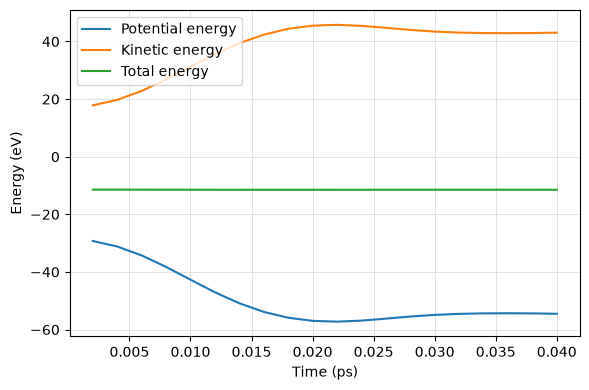

In [27]:
# Describe the interatomic interactions with the Effective Medium Theory (EMT)
water_molecules.calc = TIP3P()

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 1
dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  # 1 fs time step.

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NVE simulation of equilibrated water ')
printenergy(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 2
for i in range(20):
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)
    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


## Physical scanning of 2 water molecules

In [78]:
from ase.calculators.lj import LennardJones

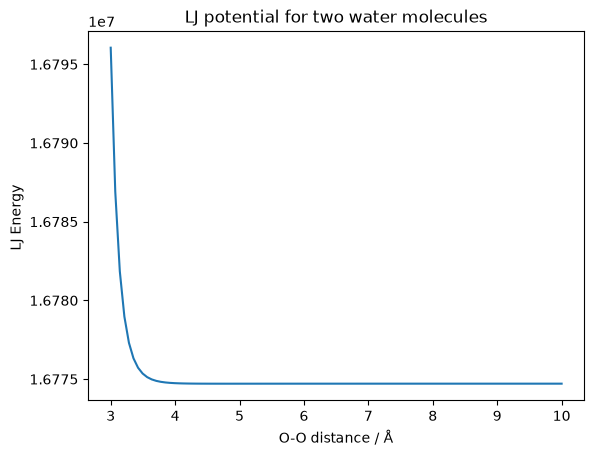

In [90]:
sigma = 3.15
epsilon = 0.65

distances = np.linspace(3, 10, 100)  
energies = []

for d in distances:
    atoms = Atoms('OHHOHH',
                positions=[
    [0.,     0.,     0.  ],   # O1
    [-0.757, -0.586, 0.  ],   # H1a
    [0.757,  -0.586, 0.  ],   # H1b
    [d,      0.,     0.  ],   # O2
    [d-0.757,-0.586, 0.  ],   # H2a
    [d+0.757,-0.586, 0.  ],   # H2b
], pbc=False)
    
    atoms.calc = LennardJones(sigma=sigma, epsilon=epsilon)
    energies.append(atoms.get_potential_energy())

plt.plot(distances, energies)
plt.title('LJ potential for two water molecules')
plt.xlabel('O-O distance / Å')
plt.ylabel('LJ Energy ')
plt.show()

In [45]:
distances = np.linspace(2.5, 10, 3)
distances

array([ 2.5 ,  6.25, 10.  ])

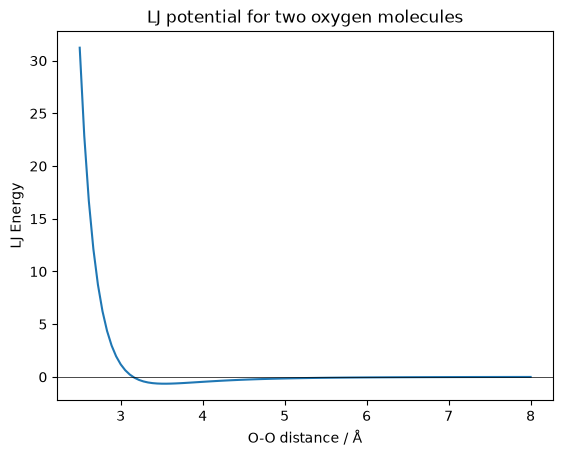

In [ ]:
from ase import Atoms
from ase.calculators.lj import LennardJones
import numpy as np
import matplotlib.pyplot as plt

# lj parameters for water 
sigma = 3.15  
epsilon = 0.65 

distances = np.linspace(2.5, 8.0, 100)
energies = []

for d in distances:
    atoms = Atoms(
        'OO',
        positions=[[0., 0., 0.],
                   [0., 0., d]]
    )
    atoms.calc = LennardJones(sigma=sigma, epsilon=epsilon)
    energies.append(atoms.get_potential_energy())

plt.figure()
plt.plot(distances, energies)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('O-O distance / Å')
plt.ylabel('LJ Energy')
plt.title('LJ potential for two oxygen molecules')

plt.show()